In [67]:
#imports
import os
import sys
import io
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import pandas as pd
import numpy as np
from tqdm import tqdm
import cv2
from PIL import Image
import torch

source_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(source_path)

# parameter initialization

In [164]:
#models: ['trocr-small-stage1', 'trocr-small-handwritten', 'trocr-base-handwritten','trocr-large-handwritten', 'trocr-large-stage1', 'trocr-base-stage1'
#'vit-base-patch16-224-in21k', 'clip-vit-large-patch14',
#'vitstr_base', 'crnn_vgg16_bn', 'dresnet50' ,
#'alexnet', 'vgg16', 'googlenet', resnet18,deit-tiny, 'resnet50',
N_max=282
patches=True
huggingface=False
pooling=False # if true in transformer mdoels use pooling, if false only the cls token
custom_transform=False
transform_mode='resize'
save_h5=False
selected_model = 'sar_resnet31' 

truncation = 'remove head'
running = 'new-laptop'
saved = 'old-laptop'
model_mode = 'truncated' #'as is', 'truncated
batch_size = 32
select_cls=False
num_workers=0
normalization=True

# model and transform initialization

In [165]:
transform = u_transforms.get_transform(selected_model, use_patches=patches, custom=custom_transform, mode=transform_mode)
model = model_utils.get_model(name=selected_model, mode=model_mode, pretrained=True, truncation=truncation)

  0%|          | 0/221870095 [00:00<?, ?it/s]

# model analysis

Device is:  cuda
255 0


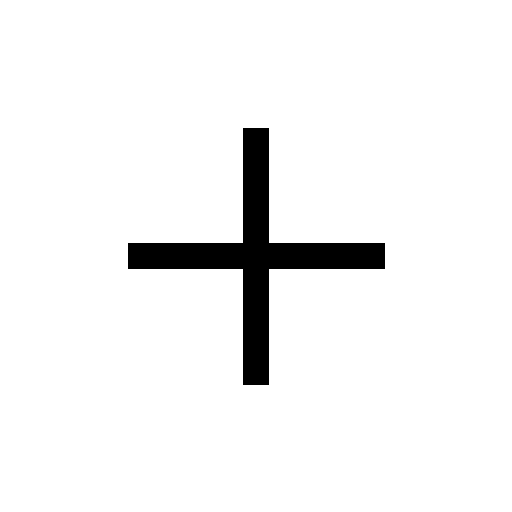

In [ ]:
import gc

torch.cuda.empty_cache()
gc.collect()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device is: ",device)
model = model.to(device)
test_image=generate_cross_image(cross_width_ratio=0.5, cross_height_ratio=0.5)
print(np.max(test_image),np.min(test_image))
display(Image.fromarray(test_image))

min,max -2.3479729 1.0304054


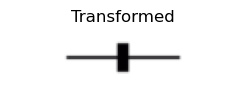

Output shape:  torch.Size([1, 512])


In [167]:
#real_image = Image.open('/content/0101_4.jpg').convert('RGB')
output=compute_output(model, device, transform, huggingface,test_image)
print("Output shape: ", output.shape)

In [168]:
n_par,n_layers = count_model_parameters_and_layers(model)
print('n parameters',f"{n_par:.3e}")
print('n layers',n_layers)
print(transform)

n parameters 4.598e+07
n layers 1
Compose(
    Resize(size=(32, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.694, 0.695, 0.693], std=[0.299, 0.296, 0.301])
)


# functions

In [158]:
import matplotlib.pyplot as plt
def reload_modules():
    import importlib
    import utils.model_utils as model_utils
    import utils.utils_transforms as u_transforms

    importlib.reload(model_utils)
    importlib.reload(u_transforms)

    return model_utils, u_transforms
model_utils, u_transforms = reload_modules()
def generate_cross_image(resolution=(512, 512), cross_width_ratio=0.1, cross_height_ratio=0.1, color=(0, 0, 0)):
    """
    Generates an RGB image with a cross at its center.

    Args:
        resolution (tuple): The resolution of the image (width, height).
        cross_width_ratio (float): The ratio of the cross width to the image width.
        cross_height_ratio (float): The ratio of the cross height to the image height.
        color (tuple): The color of the cross in RGB format (0-255).

    Returns:
        np.ndarray: The generated image as a NumPy array.
    """
    width, height = resolution
    image = np.zeros((height, width, 3), dtype=np.uint8)+255

    cross_width = int(width * cross_width_ratio)
    cross_height = int(height * cross_height_ratio)

    # Draw horizontal bar of the cross
    start_x = (width - cross_width) // 2
    end_x = start_x + cross_width
    start_y_h = (height - int(height * 0.05)) // 2 # Small height for the horizontal bar
    end_y_h = start_y_h + int(height * 0.05)
    cv2.rectangle(image, (start_x, start_y_h), (end_x, end_y_h), color, -1)

    # Draw vertical bar of the cross
    start_x_v = (width - int(width * 0.05)) // 2 # Small width for the vertical bar
    end_x_v = start_x_v + int(width * 0.05)
    start_y = (height - cross_height) // 2
    end_y = start_y + cross_height
    cv2.rectangle(image, (start_x_v, start_y), (end_x_v, end_y), color, -1)

    return image
def compute_output(model, device, transform, huggingface,test_image, show_image=True):
    if isinstance(test_image, np.ndarray):
      patch=Image.fromarray(test_image)
    else:
      patch = test_image
    if huggingface:
        # the transform is actually an huggingface processor in this case
        inputs = transform(images=patch, return_tensors="pt")
        # Remove batch dimension from inputs
        patch = inputs['pixel_values'].squeeze()
    else:
        patch = transform(patch)

    if show_image:
      img_np = patch.permute(1, 2, 0).cpu().numpy()
      # Normalize if needed
      print("min,max",img_np.min(),img_np.max())
      img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

      plt.subplot(1, 2, 2)
      plt.imshow(img_np)
      plt.title("Transformed")
      plt.axis('off')
      plt.show()

    patch = patch.to(device)
    output = model(patch.unsqueeze(0))
    return output
# Example usage:
# image = generate_cross_image()
# Image.fromarray(image).save("cross_image.png")
def count_model_parameters_and_layers(model):
    """
    Counts the number of parameters and layers in a PyTorch model.

    Args:
        model (torch.nn.Module): The PyTorch model.

    Returns:
        tuple: A tuple containing the total number of parameters and the number of layers.
    """
    num_parameters = sum(p.numel() for p in model.parameters())
    num_layers = len(list(model.children()))
    return num_parameters, num_layers

# Example usage:
# num_params, num_layers = count_model_parameters_and_layers(model)
# print(f"Number of parameters: {num_params}")
# print(f"Number of layers: {num_layers}")